# SETUP

## IMPORT LIBRARIES

In [6]:
# import libraries
from google.colab import files
import pandas as pd
import numpy as np
from sklearn import metrics
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [7]:
# autokeras
!pip install autokeras
import autokeras as ak

In [8]:
#!pip install git+https://github.com/keras-team/keras-tuner.git@1.0.2rc1
# don't know if need - added during process of trying to get additional metrics - did not work

In [9]:
!pip install keras
import keras as keras

## LOAD DATAFILES

In [10]:
# load Cleveland datafile
cleveland_csv_path = "processed.cleveland.data"
cleveland_data = pd.read_csv(cleveland_csv_path, header = None)
# assign column names
##--original
# cleveland_data.set_axis(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
#                   'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
#                   'ca', 'thal', 'num'], axis = 1, inplace = True)
##--modified
cleveland_data.columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                  'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
                  'ca', 'thal', 'num']

##--added
cleveland_data = cleveland_data.replace("?", np.nan)

cleveland_data["ca"] = pd.to_numeric(cleveland_data["ca"], errors="coerce")
cleveland_data["thal"] = pd.to_numeric(cleveland_data["thal"], errors="coerce")

cleveland_data = cleveland_data.dropna(subset=["ca", "thal"]).copy()

In [11]:
# load Hungarian datafile
hungarian_csv_path = "reprocessed.hungarian.data"
hungarian_data = pd.read_csv(hungarian_csv_path, delimiter = ' ', header = None)
# assign column names
##--original
# hungarian_data.set_axis(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
#                   'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
#                   'ca', 'thal', 'num'], axis = 1, inplace = True)
##--modified
hungarian_data.columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                  'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
                  'ca', 'thal', 'num']

In [12]:
# load Switzerland datafile
switzerland_csv_path = "processed.switzerland.data"
switzerland_data = pd.read_csv(switzerland_csv_path, header = None)
# assign column names
##--original
# switzerland_data.set_axis(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
#                   'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
#                   'ca', 'thal', 'num'], axis = 1, inplace = True)
##--modified
switzerland_data.columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                  'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
                  'ca', 'thal', 'num']

In [13]:
# load VA datafile
va_csv_path = "processed.va.data"
va_data = pd.read_csv(va_csv_path, header = None)
# assign column names
##--original
# va_data.set_axis(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
#                   'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
#                   'ca', 'thal', 'num'], axis = 1, inplace = True)
##--modified
va_data.columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                  'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
                  'ca', 'thal', 'num']

## DEFINE LABEL COLUMN

In [14]:
# Define label column
heart_label = 'num'

# CLEVELAND

## SIMPLEST OF MODELS
zero data preprocessing performed

### TAKE A PEEK

In [15]:
cleveland_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [16]:
cleveland_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  num       297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 34.8 KB


### BINARY MODELING
(Note: "Cleveland" label here would need to be revised because used in Slightly Better Model below when split the data, if care.)

#### PREPARE DATA

In [17]:
# make copy for binary labeling
cleveland_binary = cleveland_data.copy()
cleveland_binary['num'][cleveland_binary['num'] > 0] = 1
cleveland_binary.head()

/tmp/ipython-input-17-20290669.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  cleveland_binary['num'][cleveland_binary['num'] > 0] = 1
/tmp/ipython-input-17-20290669.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy o

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [18]:
# split the binary data
from sklearn.model_selection import train_test_split
cleveland_train, cleveland_test = train_test_split(cleveland_binary, test_size=0.2, random_state=42)
cleveland_test_labels = cleveland_test[heart_label]
cleveland_test_nolabel = cleveland_test.drop([heart_label], axis=1)
cleveland_train_labels = cleveland_train[heart_label]
cleveland_train_nolabel = cleveland_train.drop([heart_label], axis=1)
cleveland_train.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
105,54.0,1.0,2.0,108.0,309.0,0.0,0.0,156.0,0.0,0.0,1.0,0.0,7.0,0
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,1
81,53.0,0.0,4.0,130.0,264.0,0.0,2.0,143.0,0.0,0.4,2.0,0.0,3.0,0
204,43.0,1.0,4.0,110.0,211.0,0.0,0.0,161.0,0.0,0.0,1.0,0.0,7.0,0
107,57.0,1.0,3.0,128.0,229.0,0.0,2.0,150.0,0.0,0.4,2.0,1.0,7.0,1


#### MODEL - TRAIN & EVALUATE

In [19]:
# Instantiate classifier
clf = ak.StructuredDataClassifier(overwrite=True, max_trials = 3)

In [20]:
# Fit model
##--original
# clf.fit(cleveland_train_nolabel, cleveland_train_labels)
##--modified
X_cleveland_train_ak = cleveland_train_nolabel.to_numpy(dtype=np.float32)
y_cleveland_train_ak = cleveland_train_labels.to_numpy(dtype=np.int64)

clf = ak.StructuredDataClassifier(
    overwrite=True,
    seed=42,
    max_trials=2,
    project_name="ak_cleveland_binary"
)

clf.fit(
    X_cleveland_train_ak,
    y_cleveland_train_ak,
    epochs=1,
    validation_split=0.2
)

Trial 2 Complete [00h 00m 09s]
val_accuracy: 0.7659574747085571

Best val_accuracy So Far: 0.7659574747085571
Total elapsed time: 00h 00m 20s
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.6271 - loss: 0.6446


In [21]:
##--original
# # Predict with best model
# cleveland_pred_y = clf.predict(cleveland_test_nolabel)
##--modified
X_cleveland_test_ak = cleveland_test_nolabel.to_numpy(dtype=np.float32)
cleveland_pred_y = clf.predict(X_cleveland_test_ak).reshape(-1)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 13))
  warnings.warn(msg)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step


In [22]:
# Evaluate best model with testing data
##--original
#print(clf.evaluate(cleveland_test_nolabel, cleveland_test_labels))
##--modified
y_cleveland_test_ak = cleveland_test_labels.to_numpy(dtype=np.int64)
print(clf.evaluate(X_cleveland_test_ak, y_cleveland_test_ak))

# loss: 0.4278 & accuracy: 0.8689 with max_trials=3 & epochs=10 (elapsed time = 14s; one run took as long as 1m 24s)
#       but rerunning may produce drastically different results (i.e. 0.8033)
#       too few trials and epochs; too much "luck of the draw" (not likely ... see default settings notes)
# default settings (100 max_trials, 1000 epochs) (39m 9s)
# loss: 0.3654 & accuracy: 0.8361
#       comparable/same accuracies as was getting with very simple version
#       no reason to run model for 39m when get similar results in 14s

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 239ms/step - accuracy: 0.8375 - loss: 0.5126
[0.5185986161231995, 0.8500000238418579]


#### TABLES, PLOTS, AND SUCH

In [23]:
# confusion matrix
confusion_matrix(cleveland_test_labels, cleveland_pred_y)

array([[35,  1],
       [ 8, 16]])

### MULTICLASS MODELING

(only ~50% accuracy so far!)


Future research thought: Multiclass classification. OneVsAll for have:don't have heart disease and then Mutliclass for specific type/severity of heart disease may be more effective.

In [24]:
cleveland_binary.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [25]:
cleveland_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [26]:
# split the multiclass data
from sklearn.model_selection import train_test_split
mccleveland_train, mccleveland_test = train_test_split(cleveland_data, test_size=0.2, random_state=42)
mccleveland_test_labels = mccleveland_test[heart_label]
mccleveland_test_nolabel = mccleveland_test.drop([heart_label], axis=1)
mccleveland_train_labels = mccleveland_train[heart_label]
mccleveland_train_nolabel = mccleveland_train.drop([heart_label], axis=1)
mccleveland_train.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
72,62.0,1.0,4.0,120.0,267.0,0.0,0.0,99.0,1.0,1.8,2.0,2.0,7.0,1
110,61.0,0.0,4.0,145.0,307.0,0.0,2.0,146.0,1.0,1.0,2.0,0.0,7.0,1
228,54.0,1.0,4.0,110.0,206.0,0.0,2.0,108.0,1.0,0.0,2.0,1.0,3.0,3
41,40.0,1.0,1.0,140.0,199.0,0.0,0.0,178.0,1.0,1.4,1.0,0.0,7.0,0
265,42.0,1.0,4.0,136.0,315.0,0.0,0.0,125.0,1.0,1.8,2.0,0.0,6.0,2


In [27]:
##--original
# # Instantiate classifier
# mcclf = ak.StructuredDataClassifier(overwrite=True, max_trials=3)

##--modified
X_mccleveland_train_ak = mccleveland_train_nolabel.to_numpy(dtype=np.float32)
y_mccleveland_train_ak = mccleveland_train_labels.to_numpy(dtype=np.int64)

mcclf = ak.StructuredDataClassifier(
    overwrite=True,
    seed=42,
    max_trials=2,
    project_name="ak_cleveland_multiclass"
)

mcclf.fit(
    X_mccleveland_train_ak,
    y_mccleveland_train_ak,
    epochs=1,
    validation_split=0.2
)

Trial 2 Complete [00h 00m 04s]
val_accuracy: 0.6170212626457214

Best val_accuracy So Far: 0.6170212626457214
Total elapsed time: 00h 00m 08s
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.3492 - loss: 1.5585


In [28]:
# # Fit model
# mcclf.fit(mccleveland_train_nolabel, mccleveland_train_labels)

In [29]:
##--ERROR in research, clf used instead of mcclf???
##--original
# # Predict with best model
# mccleveland_pred_y = clf.predict(mccleveland_test_nolabel)
##--modified
X_mccleveland_test_ak = mccleveland_test_nolabel.to_numpy(dtype=np.float32)
y_mccleveland_test_ak = mccleveland_test_labels.to_numpy(dtype=np.int64)
mccleveland_pred_y = clf.predict(X_mccleveland_test_ak).reshape(-1)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 13))
  warnings.warn(msg)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


In [30]:
##--original
# # Evaluate best model with testing data
# print(mcclf.evaluate(mccleveland_test_nolabel, mccleveland_test_labels))
##--modified
print(mcclf.evaluate(X_mccleveland_test_ak, y_mccleveland_test_ak))

# loss: 1.2442 & accuracy: 0.5082 ... !!!!!!!!!!!
# May be best to stick with binary label, like everyone else has previously.

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 356ms/step - accuracy: 0.6188 - loss: 1.3679
[1.378001093864441, 0.6000000238418579]


In [31]:
# confusion matrix
#from sklearn.metrics import classification_report, confusion_matrix
#confusion_matrix(mccleveland_test_labels, mccleveland_pred_y)

# ERROR WHEN TRY TO RUN THIS CONFUSION MATRIX

## SLIGHTLY BETTER MODEL
no missing values & stratified sampling

### DATA PREPROCESSING

#### MISSING VALUES

In [32]:
# make copy of original dataframe
cleveland = cleveland_data.copy()

In [33]:
# check for missing values
cleveland.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  num       297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 34.8 KB


In [34]:
# replace '?' values with NaN so can impute
##--original
# cleveland['thal'].replace('?', np.NaN, inplace=True)
##--modified
cleveland['thal'].replace('?', np.nan, inplace=True)

cleveland['thal'] = cleveland['thal'].astype(float)
##--original
# cleveland['ca'].replace('?', np.NaN, inplace=True)
##--modified
cleveland['ca'].replace('?', np.nan, inplace=True)

cleveland['ca'] = cleveland['ca'].astype(float)
cleveland.tail() # to verify didn't mess up dataframe IDs

/tmp/ipython-input-34-170674292.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cleveland['thal'].replace('?', np.nan, inplace=True)
/tmp/ipython-input-34-170674292.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
297,57.0,0.0,4.0,140.0,241.0,0.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0,1
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [35]:
# make dataset version for plotting purposes
cleveland_for_plot = cleveland.copy()

In [36]:
# impute with mode as 'thal' and 'ca' (attributes w/ missing values) are discrete
imputeMode = SimpleImputer(strategy="most_frequent") # create mode imputer
imputeMode.fit(cleveland) # fit - learns the data
imputed = imputeMode.transform(cleveland) # transform - imputes with chosen strategy
cleveland = pd.DataFrame(imputed, columns=cleveland.columns, index=cleveland.index) # back to pandas DataFrame
cleveland.info() # check for missing values

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  num       297 non-null    float64
dtypes: float64(14)
memory usage: 34.8 KB


In [37]:
cleveland.head() # check for anything obviously wonky

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0


#### BINARY LABEL
(multiclass for "future research")

In [38]:
cleveland['num'][cleveland['num'] > 0] = 1
cleveland.head()

/tmp/ipython-input-38-3893717676.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  cleveland['num'][cleveland['num'] > 0] = 1


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0


#### STRATIFIED SAMPLING

(due to difference in sex representation)

In [39]:
##--original
# cleveland_strat = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
# for train_index, test_index in cleveland_strat.split(cleveland, cleveland["num"]):
#   cleveland_strat_train = cleveland.loc[train_index]
#   cleveland_strat_test = cleveland.loc[test_index]
##--modified
cleveland_strat = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in cleveland_strat.split(cleveland, cleveland["num"]):
  cleveland_strat_train = cleveland.iloc[train_index]
  cleveland_strat_test = cleveland.iloc[test_index]

In [40]:
cleveland_strat_test["num"].value_counts()/len(cleveland_strat_test)

,count
num,
0.0,0.533333
1.0,0.466667


In [41]:
cleveland_strat_train["num"].value_counts()/len(cleveland_strat_train)

,count
num,
0.0,0.540084
1.0,0.459916


Less significant for Cleveland and Statlog datasets, which have less dramatic difference in sex representation in data, but different for other three datasets.

In [42]:
# split stratified data
cleveland_strat_train_X = cleveland_strat_train.drop([heart_label], axis=1)
cleveland_strat_train_y = cleveland_strat_train[heart_label]
cleveland_strat_test_X = cleveland_strat_test.drop([heart_label], axis=1)
cleveland_strat_test_y = cleveland_strat_test[heart_label]
cleveland_strat_train_X.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
45,58.0,1.0,3.0,112.0,230.0,0.0,2.0,165.0,0.0,2.5,2.0,1.0,7.0
111,56.0,1.0,4.0,125.0,249.0,1.0,2.0,144.0,1.0,1.2,2.0,1.0,3.0
32,64.0,1.0,3.0,140.0,335.0,0.0,0.0,158.0,0.0,0.0,1.0,0.0,3.0
189,69.0,1.0,3.0,140.0,254.0,0.0,2.0,146.0,0.0,2.0,2.0,3.0,7.0
11,56.0,0.0,2.0,140.0,294.0,0.0,2.0,153.0,0.0,1.3,2.0,0.0,3.0


### BINARY MODEL

In [43]:
##--original
# clev_clf = ak.StructuredDataClassifier(overwrite=True, seed = 42) # instantiate classifier
# clev_clf.fit(cleveland_strat_train_X, cleveland_strat_train_y) # fit model
##--modified
X_clev_strat_train_ak = cleveland_strat_train_X.to_numpy(dtype=np.float32)
y_clev_strat_train_ak = cleveland_strat_train_y.to_numpy(dtype=np.int64)

clev_clf = ak.StructuredDataClassifier(
    overwrite=True,
    seed=42,
    max_trials=2,
    project_name="ak_cleveland_stratified"
)

clev_clf.fit(
    X_clev_strat_train_ak,
    y_clev_strat_train_ak,
    epochs=1,
    validation_split=0.2
)

Trial 2 Complete [00h 00m 03s]
val_accuracy: 0.7446808218955994

Best val_accuracy So Far: 0.7446808218955994
Total elapsed time: 00h 00m 07s
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.5173 - loss: 0.6817


In [44]:
##--original
# cleveland_strat_pred_y = clev_clf.predict(cleveland_strat_test_X) # predict with best model
# print(clev_clf.evaluate(cleveland_strat_test_X, cleveland_strat_test_y)) # evaluate best model with testing data
##--modified
X_clev_strat_test_ak = cleveland_strat_test_X.to_numpy(dtype=np.float32)
y_clev_strat_test_ak = cleveland_strat_test_y.to_numpy(dtype=np.int64)
cleveland_strat_pred_y = clev_clf.predict(X_clev_strat_test_ak).reshape(-1)
print(clev_clf.evaluate(X_clev_strat_test_ak, y_clev_strat_test_ak))

# pretty much same accuracy achieved as before removing missing values, but makes sense to do so regardless
# (missing values removed only)
# (   accuracies w/ max_trials=3 & default epochs: 0.8525, 0.8852, 0.8689)
# (also stratified sampling by sex)
# (   accuracies w/ max_trials=3 & default epochs: 0.7377, 0.8689)
# (   accuracies w/ max_trials=10 & default epochs: 0.6066 (1m 3s), 0.8852 (58s))
# (   accuracies w/ max_trials=100 & default epochs: 0.8689 (13m 25s))
# default settings 03/24 run - accuracy 0.5902 and run time 17m 49s - NOT CONFIDENT THIS ACCURACY NOT A TYPO AND ACTUALLY LOSS VALUE

# default settings 04/09 run - accuracy 0.8033 and run time 6m 35s

# FOR F1 SCORE
# default settings 04/16 run1 - accuracy 0.8033 and run time 9m 42s

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 13))
  warnings.warn(msg)


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - accuracy: 0.8257 - loss: 0.4996
[0.5039764046669006, 0.8166666626930237]


In [45]:
# view model parameters
clev_model_0416r1 = clev_clf.export_model()
clev_model_0416r1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 13)             │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head_1           │ (None, 1)              │             0 │
│ (Activation)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,868 (46.36 KB)

 Trainable params: 11,841 (46.25 KB)

 Non-trainable params: 27 (112.00 B)

In [46]:
#keras.metrics.AUC(curve="ROC")

# grrr... still struggling getting any additional metrics from autokeras or keras

In [47]:
# save confusion matrix
clev_0416_r1 = confusion_matrix(cleveland_strat_test_y, cleveland_strat_pred_y)

In [48]:
# show confusion matrix
clev_0416_r1

array([[30,  2],
       [ 9, 19]])

In [49]:
# compute f1 score
import sklearn

In [50]:
from sklearn.metrics import f1_score
sklearn.metrics.f1_score(cleveland_strat_test_y, cleveland_strat_pred_y)

0.7755102040816326

### BINARY WITH F1
having trouble getting f1 to work for autokeras (I don't seem to be alone) ...
going to resort to manual calculation

In [51]:
#def f1_score(cleveland_strat_test_y, cleveland_strat_pred_y):
#  ...

In [52]:
#clev_f1_clf = ak.StructuredDataClassifier(
#    overwrite=True, seed=42,

    # Wrap the function into a Keras Tuner Objective
    # and pass it to AutoKeras.

    # Direction can be 'min' or 'max'
    # meaning we want to minimize or maximize the metric.

    # 'val_f1_score' is just add a 'val_' prefix
    # to the function name or the metric name.

#    objective=kerastuner.Objective('val_f1_score', direction='max'),
    # Include it as one of the metrics.
#    metrics=[f1_score],
#)

In [53]:
#cleveland_f1_y = clev_f1_clf.predict(cleveland_strat_test_X) # predict with best model
#print(clev_f1_clf.evaluate(cleveland_strat_test_X, cleveland_strat_test_y)) # evaluate best model with testing data

## REDUCED FOR CORRELATION
(incl. no missing values & stratified sampling)

### DATA PREPROCESSING

#### REMOVE UNCORRELATED ATTRIBUTES

In [54]:
# check correlation
cleveland_correlation = cleveland.corr()
cleveland_correlation['num'].sort_values()

,num
thalach,-0.423817
fbs,0.003167
chol,0.080285
trestbps,0.153490
restecg,0.166343
age,0.227075
sex,0.278467
slope,0.333049
cp,0.408945
exang,0.421355


In [55]:
cleveland.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  num       297 non-null    float64
dtypes: float64(14)
memory usage: 34.8 KB


In [56]:
# eliminate columns with correlation less than abs(0.2)
drop_columns = ['fbs', 'chol', 'trestbps', 'restecg']
cleveland_downsized = cleveland.drop(columns = drop_columns)
cleveland_downsized.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      297 non-null    float64
 1   sex      297 non-null    float64
 2   cp       297 non-null    float64
 3   thalach  297 non-null    float64
 4   exang    297 non-null    float64
 5   oldpeak  297 non-null    float64
 6   slope    297 non-null    float64
 7   ca       297 non-null    float64
 8   thal     297 non-null    float64
 9   num      297 non-null    float64
dtypes: float64(10)
memory usage: 25.5 KB


#### STRATIFIED SPLIT OF DATA

In [58]:
##--original
# cleveland_downsized_strat = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
# for train_index, test_index in cleveland_downsized_strat.split(cleveland_downsized, cleveland_downsized["num"]):
#   cleveland_downsized_strat_train = cleveland_downsized.loc[train_index]
#   cleveland_downsized_strat_test = cleveland_downsized.loc[test_index]
##--modified
cleveland_downsized_strat = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in cleveland_downsized_strat.split(cleveland_downsized, cleveland_downsized["num"]):
  cleveland_downsized_strat_train = cleveland_downsized.iloc[train_index]
  cleveland_downsized_strat_test = cleveland_downsized.iloc[test_index]

In [59]:
cleveland_downsized_strat_test["num"].value_counts()/len(cleveland_downsized_strat_test)

,count
num,
0.0,0.533333
1.0,0.466667


In [60]:
cleveland_downsized_strat_train["num"].value_counts()/len(cleveland_downsized_strat_train)

,count
num,
0.0,0.540084
1.0,0.459916


In [61]:
# split stratified data
cleveland_downsized_strat_train_X = cleveland_downsized_strat_train.drop([heart_label], axis=1)
cleveland_downsized_strat_train_y = cleveland_downsized_strat_train[heart_label]
cleveland_downsized_strat_test_X = cleveland_downsized_strat_test.drop([heart_label], axis=1)
cleveland_downsized_strat_test_y = cleveland_downsized_strat_test[heart_label]
cleveland_downsized_strat_train_X.sample(5)

,age,sex,cp,thalach,exang,oldpeak,slope,ca,thal
45,58.0,1.0,3.0,165.0,0.0,2.5,2.0,1.0,7.0
111,56.0,1.0,4.0,144.0,1.0,1.2,2.0,1.0,3.0
32,64.0,1.0,3.0,158.0,0.0,0.0,1.0,0.0,3.0
189,69.0,1.0,3.0,146.0,0.0,2.0,2.0,3.0,7.0
11,56.0,0.0,2.0,153.0,0.0,1.3,2.0,0.0,3.0


### BINARY MODELING

In [63]:
##--original
# clev_corr_clf = ak.StructuredDataClassifier(overwrite=True, seed=42) # instantiate classifier
# clev_corr_clf.fit(cleveland_downsized_strat_train_X, cleveland_downsized_strat_train_y) # fit model
##--modified
X_clev_down_train_ak = cleveland_downsized_strat_train_X.to_numpy(dtype=np.float32)
y_clev_down_train_ak = cleveland_downsized_strat_train_y.to_numpy(dtype=np.int64)

clev_corr_clf = ak.StructuredDataClassifier(
    overwrite=True,
    seed=42,
    max_trials=2,
    project_name="ak_cleveland_downsized_stratified"
)

clev_corr_clf.fit(
    X_clev_down_train_ak,
    y_clev_down_train_ak,
    epochs=1,
    validation_split=0.2
)

Trial 2 Complete [00h 00m 04s]
val_accuracy: 0.7872340679168701

Best val_accuracy So Far: 0.7872340679168701
Total elapsed time: 00h 00m 08s
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.5819 - loss: 0.6760


In [64]:
##--original
# cleveland_downsized_strat_pred_y = clev_corr_clf.predict(cleveland_downsized_strat_test_X) # predict with best model
# print(clev_corr_clf.evaluate(cleveland_downsized_strat_test_X, cleveland_downsized_strat_test_y)) # evaluate best model with testing data
##--modified
X_clev_down_test_ak = cleveland_downsized_strat_test_X.to_numpy(dtype=np.float32)
y_clev_down_test_ak = cleveland_downsized_strat_test_y.to_numpy(dtype=np.int64)
cleveland_downsized_strat_pred_y = clev_corr_clf.predict(X_clev_down_test_ak).reshape(-1)
print(clev_corr_clf.evaluate(X_clev_down_test_ak, y_clev_down_test_ak))

# (accuracies w/ max_trials=3 & default epochs: 0.6066 (4m 7s), 0.8033 (13s))

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 9))
  warnings.warn(msg)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - accuracy: 0.8806 - loss: 0.5186
[0.5201122164726257, 0.8833333253860474]


In [66]:
# view model parameters
clev_corr_model = clev_corr_clf.export_model()
##--ERROR model does not exist, presumably clev_corr_model should be used???
##--original
#model.summary()
##--modified
clev_corr_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head_1           │ (None, 1)              │             0 │
│ (Activation)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,836 (42.33 KB)

 Trainable params: 10,817 (42.25 KB)

 Non-trainable params: 19 (80.00 B)

In [67]:
# compute F1 score
import sklearn
from sklearn.metrics import f1_score
sklearn.metrics.f1_score(cleveland_downsized_strat_test_y, cleveland_downsized_strat_pred_y)

0.8771929824561403

# HUNGARIAN

## TAKE A PEEK

In [68]:
hungarian_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,40.0,1.0,2.0,140.0,289.0,0.0,0.0,172.0,0.0,0.0,-9.0,-9.0,-9.0,0.0
1,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0,-9.0,-9.0,1.0
2,37.0,1.0,2.0,130.0,283.0,0.0,1.0,98.0,0.0,0.0,-9.0,-9.0,-9.0,0.0
3,48.0,0.0,4.0,138.0,214.0,0.0,0.0,108.0,1.0,1.5,2.0,-9.0,-9.0,3.0
4,54.0,1.0,3.0,150.0,-9.0,0.0,0.0,122.0,0.0,0.0,-9.0,-9.0,-9.0,0.0


In [69]:
hungarian_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    float64
 1   sex       294 non-null    float64
 2   cp        294 non-null    float64
 3   trestbps  294 non-null    float64
 4   chol      294 non-null    float64
 5   fbs       294 non-null    float64
 6   restecg   294 non-null    float64
 7   thalach   294 non-null    float64
 8   exang     294 non-null    float64
 9   oldpeak   294 non-null    float64
 10  slope     294 non-null    float64
 11  ca        294 non-null    float64
 12  thal      294 non-null    float64
 13  num       294 non-null    float64
dtypes: float64(14)
memory usage: 32.4 KB


## SIMPLEST OF MODELS - BINARY
(mininimal preprocessing)
CURRENTLY STRUGGLING WITH AN ERROR HERE

#### PREPARE DATA

In [70]:
# make copy of original dataframe
hungarian_basic = hungarian_data.copy()

In [72]:
# convert unknowns (-9.0) to NaN
##--original
# hungarian_basic.replace(-9.0, np.NaN, inplace=True)
##--modified
hungarian_basic.replace(-9.0, np.nan, inplace=True)

In [73]:
# make copy for binary labeling
hungarian_basic['num'][hungarian_basic['num'] > 0] = 1
hungarian_basic.head()

/tmp/ipython-input-73-3732086967.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  hungarian_basic['num'][hungarian_basic['num'] > 0] = 1


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,40.0,1.0,2.0,140.0,289.0,0.0,0.0,172.0,0.0,0.0,NaN,NaN,NaN,0.0
1,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0,NaN,NaN,1.0
2,37.0,1.0,2.0,130.0,283.0,0.0,1.0,98.0,0.0,0.0,NaN,NaN,NaN,0.0
3,48.0,0.0,4.0,138.0,214.0,0.0,0.0,108.0,1.0,1.5,2.0,NaN,NaN,1.0
4,54.0,1.0,3.0,150.0,NaN,0.0,0.0,122.0,0.0,0.0,NaN,NaN,NaN,0.0


In [74]:
# try dropping slope, ca, and thal
hungarian_basic.drop(['slope', 'ca', 'thal', ], axis=1, inplace=True) # did not fix error

In [75]:
# split the binary data
from sklearn.model_selection import train_test_split
hungarian_basic_train, hungarian_basic_test = train_test_split(hungarian_basic, test_size=0.2, random_state=42)
hungarian_basic_test_labels = hungarian_basic_test[heart_label]
hungarian_basic_test_nolabel = hungarian_basic_test.drop([heart_label], axis=1)
hungarian_basic_train_labels = hungarian_basic_train[heart_label]
hungarian_basic_train_nolabel = hungarian_basic_train.drop([heart_label], axis=1)
hungarian_basic_train.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
100,65.0,1.0,4.0,130.0,275.0,0.0,1.0,115.0,1.0,1.0,1.0
79,49.0,1.0,4.0,130.0,206.0,0.0,0.0,170.0,0.0,0.0,1.0
169,58.0,1.0,4.0,135.0,222.0,0.0,0.0,100.0,0.0,0.0,0.0
11,58.0,1.0,2.0,136.0,164.0,0.0,1.0,99.0,1.0,2.0,1.0
114,49.0,0.0,3.0,130.0,207.0,0.0,1.0,135.0,0.0,0.0,0.0


In [76]:
hungarian_basic_train_labels

,num
97,0.0
63,1.0
17,0.0
215,1.0
219,0.0
...,...
188,1.0
71,0.0
106,0.0
270,0.0


#### MODEL - TRAIN & EVALUATE

In [78]:
##--original
# clf = ak.StructuredDataClassifier(overwrite=True, seed=42) # Instantiate classifier
# clf.fit(hungarian_basic_train_nolabel, hungarian_basic_train_labels) # Fit model
##--modified
X_hung_basic_train_ak = hungarian_basic_train_nolabel.to_numpy(dtype=np.float32)
y_hung_basic_train_ak = hungarian_basic_train_labels.to_numpy(dtype=np.int64)

clf = ak.StructuredDataClassifier(
    overwrite=True,
    seed=42,
    max_trials=2,
    project_name="ak_hungarian_basic"
)

clf.fit(
    X_hung_basic_train_ak,
    y_hung_basic_train_ak,
    epochs=1,
    validation_split=0.2
)

Trial 2 Complete [00h 00m 04s]
val_accuracy: 0.5744680762290955

Best val_accuracy So Far: 0.5744680762290955
Total elapsed time: 00h 00m 08s
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - accuracy: 0.4858 - loss: 1.0188


In [79]:
##--original
# # Predict with best model
# hungarian_basic_pred_y = clf.predict(hungarian_basic_test_nolabel)
# # Evaluate best model with testing data
# print(clf.evaluate(hungarian_basic_test_nolabel, hungarian_basic_test_labels))
##--modified
X_hung_basic_test_ak = hungarian_basic_test_nolabel.to_numpy(dtype=np.float32)
y_hung_basic_test_ak = hungarian_basic_test_labels.to_numpy(dtype=np.int64)
hungarian_basic_pred_y = clf.predict(X_hung_basic_test_ak).reshape(-1)
print(clf.evaluate(X_hung_basic_test_ak, y_hung_basic_test_ak))

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 10))
  warnings.warn(msg)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 431ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 269ms/step - accuracy: 0.8245 - loss: 0.7584
[0.7464096546173096, 0.8305084705352783]


#### TABLES, PLOTS, AND SUCH

In [80]:
# confusion matrix
#from sklearn.metrics import classification_report, confusion_matrix
#confusion_matrix(hungarian_basic_test_labels, hungarian_basic_pred_y)

## SLIGHTLY BETTER MODEL
no missing values & stratified sampling

### DATA PREPROCESSING

#### MISSING VALUES

In [81]:
# make copy of original dataframe
hungarian = hungarian_data.copy()

In [83]:
# convert unknowns (-9.0) to NaN
##--original
# hungarian.replace(-9.0, np.NaN, inplace=True)
##--modified
hungarian.replace(-9.0, np.nan, inplace=True)

In [84]:
# check for missing values
hungarian.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    float64
 1   sex       294 non-null    float64
 2   cp        294 non-null    float64
 3   trestbps  293 non-null    float64
 4   chol      271 non-null    float64
 5   fbs       286 non-null    float64
 6   restecg   293 non-null    float64
 7   thalach   293 non-null    float64
 8   exang     293 non-null    float64
 9   oldpeak   294 non-null    float64
 10  slope     104 non-null    float64
 11  ca        4 non-null      float64
 12  thal      28 non-null     float64
 13  num       294 non-null    float64
dtypes: float64(14)
memory usage: 32.4 KB


In [85]:
# make dataset version for plotting purposes
hungarian_for_plot = hungarian.copy()

In [86]:
# drop slope, ca, and thal due to >50% of values missing
hungarian.drop(['slope', 'ca', 'thal'], axis=1, inplace=True)

In [87]:
hungarian.tail() # check if next code block is needed

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
290,36.0,1.0,2.0,120.0,166.0,0.0,0.0,180.0,0.0,0.0,0.0
291,48.0,1.0,3.0,110.0,211.0,0.0,0.0,138.0,0.0,0.0,0.0
292,47.0,0.0,2.0,140.0,257.0,0.0,0.0,135.0,0.0,1.0,0.0
293,53.0,1.0,4.0,130.0,182.0,0.0,0.0,148.0,0.0,0.0,0.0
294,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [88]:
hungarian.drop(294,axis=0, inplace=True) # may not be necessary later # something may have gone wrong earlier, requiring it now

In [89]:
from sklearn.impute import SimpleImputer
# impute discrete values using mode ()
imputeMode = SimpleImputer(strategy="most_frequent") # create mode imputer
hungarian_disc = pd.concat([hungarian.pop(x) for x in ['fbs', 'restecg', 'exang']], axis=1) # isolate discrete
imputeMode.fit(hungarian_disc) # fit - learns the data
imputed_disc = imputeMode.transform(hungarian_disc) # transform - imputes with chosen strategy
hungarian_disc_imp = pd.DataFrame(imputed_disc, columns=hungarian_disc.columns, index=hungarian.index) # back to pandas DataFrame
hungarian_disc_imp.info() # check for missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   fbs      294 non-null    float64
 1   restecg  294 non-null    float64
 2   exang    294 non-null    float64
dtypes: float64(3)
memory usage: 7.0 KB


In [90]:
# Combine cat, cont, and remaining
from sklearn.impute import SimpleImputer
# impute continuous values using mean
imputeMean = SimpleImputer(strategy="mean") # create mode imputer
hungarian_cont = pd.concat([hungarian.pop(x) for x in ['trestbps', 'chol', 'thalach']], axis=1) # isolate continuous
imputeMean.fit(hungarian_cont) # fit - learns the data
imputed_cont = imputeMean.transform(hungarian_cont) # transform - imputes with chosen strategy
hungarian_cont_imp = pd.DataFrame(imputed_cont, columns=hungarian_cont.columns, index=hungarian.index) # back to pandas DataFrame
hungarian_cont_imp.info() # check for missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   trestbps  294 non-null    float64
 1   chol      294 non-null    float64
 2   thalach   294 non-null    float64
dtypes: float64(3)
memory usage: 7.0 KB


In [91]:
hungarian_imp = pd.concat((hungarian_cont_imp, hungarian_disc_imp, hungarian), axis=1)

In [92]:
hungarian_imp.head() # check for anything obviously wonky

,trestbps,chol,thalach,fbs,restecg,exang,age,sex,cp,oldpeak,num
0,140.0,289.000000,172.0,0.0,0.0,0.0,40.0,1.0,2.0,0.0,0.0
1,160.0,180.000000,156.0,0.0,0.0,0.0,49.0,0.0,3.0,1.0,1.0
2,130.0,283.000000,98.0,0.0,1.0,0.0,37.0,1.0,2.0,0.0,0.0
3,138.0,214.000000,108.0,0.0,0.0,1.0,48.0,0.0,4.0,1.5,3.0
4,150.0,250.848708,122.0,0.0,0.0,0.0,54.0,1.0,3.0,0.0,0.0


In [93]:
hungarian_imp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   trestbps  294 non-null    float64
 1   chol      294 non-null    float64
 2   thalach   294 non-null    float64
 3   fbs       294 non-null    float64
 4   restecg   294 non-null    float64
 5   exang     294 non-null    float64
 6   age       294 non-null    float64
 7   sex       294 non-null    float64
 8   cp        294 non-null    float64
 9   oldpeak   294 non-null    float64
 10  num       294 non-null    float64
dtypes: float64(11)
memory usage: 25.4 KB


#### BINARY LABEL
(multiclass for "future research")

In [94]:
hungarian_imp['num'][hungarian_imp['num'] > 0] = 1
hungarian_imp.value_counts('num')

/tmp/ipython-input-94-1342893202.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  hungarian_imp['num'][hungarian_imp['num'] > 0] = 1


,count
num,
0.0,188
1.0,106


#### STRATIFIED SAMPLING

(due to difference in sex representation)

In [95]:
hungarian_imp_strat = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in hungarian_imp_strat.split(hungarian_imp, hungarian_imp["num"]):
  hungarian_imp_strat_train = hungarian_imp.loc[train_index]
  hungarian_imp_strat_test = hungarian_imp.loc[test_index]

In [96]:
hungarian_imp_strat_test["num"].value_counts()/len(hungarian_imp_strat_test)

,count
num,
0.0,0.644068
1.0,0.355932


In [97]:
hungarian_imp_strat_train["num"].value_counts()/len(hungarian_imp_strat_train)

,count
num,
0.0,0.638298
1.0,0.361702


Less significant for Cleveland and Statlog datasets, which have less dramatic difference in sex representation in data, but different for other three datasets.

In [98]:
# split stratified data
hungarian_imp_strat_train_X = hungarian_imp_strat_train.drop([heart_label], axis=1)
hungarian_imp_strat_train_y = hungarian_imp_strat_train[heart_label]
hungarian_imp_strat_test_X = hungarian_imp_strat_test.drop([heart_label], axis=1)
hungarian_imp_strat_test_y = hungarian_imp_strat_test[heart_label]
hungarian_imp_strat_train_X.sample(5)

,trestbps,chol,thalach,fbs,restecg,exang,age,sex,cp,oldpeak
38,120.0,250.848708,148.0,1.0,1.0,0.0,48.0,0.0,2.0,0.0
291,110.0,211.000000,138.0,0.0,0.0,0.0,48.0,1.0,3.0,0.0
7,110.0,208.000000,142.0,0.0,0.0,0.0,54.0,1.0,2.0,0.0
243,160.0,292.000000,143.0,1.0,0.0,1.0,55.0,1.0,2.0,2.0
228,92.0,117.000000,134.0,0.0,0.0,1.0,38.0,1.0,4.0,2.5


### BINARY MODEL

In [100]:
##--original
# hung_clf = ak.StructuredDataClassifier(overwrite=True, seed = 42) # instantiate classifier
# hung_clf.fit(hungarian_imp_strat_train_X, hungarian_imp_strat_train_y) # fit model
##--modified
X_hung_imp_strat_train_ak = hungarian_imp_strat_train_X.to_numpy(dtype=np.float32)
y_hung_imp_strat_train_ak = hungarian_imp_strat_train_y.to_numpy(dtype=np.int64)

hung_clf = ak.StructuredDataClassifier(
    overwrite=True,
    seed=42,
    max_trials=2,
    project_name="ak_hungarian_imp_strat"
)

hung_clf.fit(
    X_hung_imp_strat_train_ak,
    y_hung_imp_strat_train_ak,
    epochs=1,
    validation_split=0.2
)

Trial 2 Complete [00h 00m 04s]
val_accuracy: 0.7659574747085571

Best val_accuracy So Far: 0.7659574747085571
Total elapsed time: 00h 00m 07s
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.5033 - loss: 0.6791


In [101]:
##--original
# hungarian_imp_strat_pred_y = hung_clf.predict(hungarian_imp_strat_test_X) # predict with best model
# print(hung_clf.evaluate(hungarian_imp_strat_test_X, hungarian_imp_strat_test_y)) # evaluate best model with testing data
##--modified
X_hung_imp_strat_test_ak = hungarian_imp_strat_test_X.to_numpy(dtype=np.float32)
y_hung_imp_strat_test_ak = hungarian_imp_strat_test_y.to_numpy(dtype=np.int64)
hungarian_imp_strat_pred_y = hung_clf.predict(X_hung_imp_strat_test_ak).reshape(-1)
print(hung_clf.evaluate(X_hung_imp_strat_test_ak, y_hung_imp_strat_test_ak))

# default settings 03/27 run1 - accuracy 0.8644 and run time 7m 36s
# default settings 03/27 run2 - accuracy 0.7966 and run time 10m 29s
# default settings 03/27 run3 - accuracy 0.6610 and run time 52m 27s

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 10))
  warnings.warn(msg)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 246ms/step - accuracy: 0.8784 - loss: 0.5534
[0.5683987140655518, 0.8644067645072937]


In [102]:
# view model parameters
model = hung_clf.export_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 10)             │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head_1           │ (None, 1)              │             0 │
│ (Activation)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,094 (43.34 KB)

 Trainable params: 11,073 (43.25 KB)

 Non-trainable params: 21 (88.00 B)

In [103]:
# compute F1 score
import sklearn
from sklearn.metrics import f1_score
sklearn.metrics.f1_score(hungarian_imp_strat_test_y, hungarian_imp_strat_pred_y)

0.8095238095238095

## REDUCED FOR CORRELATION
(incl. no missing values & stratified sampling)

### DATA PREPROCESSING

#### REMOVE UNCORRELATED ATTRIBUTES

In [104]:
# check correlation
hungarian_imp_correlation = hungarian_imp.corr()
hungarian_imp_correlation['num'].sort_values()

,num
thalach,-0.331074
restecg,-0.031988
trestbps,0.139582
age,0.159315
fbs,0.162869
chol,0.202372
sex,0.272781
cp,0.505864
oldpeak,0.545700
exang,0.584541


In [105]:
hungarian_imp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   trestbps  294 non-null    float64
 1   chol      294 non-null    float64
 2   thalach   294 non-null    float64
 3   fbs       294 non-null    float64
 4   restecg   294 non-null    float64
 5   exang     294 non-null    float64
 6   age       294 non-null    float64
 7   sex       294 non-null    float64
 8   cp        294 non-null    float64
 9   oldpeak   294 non-null    float64
 10  num       294 non-null    float64
dtypes: float64(11)
memory usage: 25.4 KB


In [106]:
# eliminate columns with correlation less than abs(0.2)
drop_columns = ['age', 'fbs', 'trestbps', 'restecg']
hungarian_imp_downsized = hungarian_imp.drop(columns = drop_columns)
hungarian_imp_downsized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   chol     294 non-null    float64
 1   thalach  294 non-null    float64
 2   exang    294 non-null    float64
 3   sex      294 non-null    float64
 4   cp       294 non-null    float64
 5   oldpeak  294 non-null    float64
 6   num      294 non-null    float64
dtypes: float64(7)
memory usage: 16.2 KB


#### STRATIFIED SPLIT OF DATA

In [107]:
hungarian_imp_downsized_strat = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in hungarian_imp_downsized_strat.split(hungarian_imp_downsized, hungarian_imp_downsized["num"]):
  hungarian_imp_downsized_strat_train = hungarian_imp_downsized.loc[train_index]
  hungarian_imp_downsized_strat_test = hungarian_imp_downsized.loc[test_index]

In [108]:
hungarian_imp_downsized_strat_test["num"].value_counts()/len(hungarian_imp_downsized_strat_test)

,count
num,
0.0,0.644068
1.0,0.355932


In [109]:
hungarian_imp_downsized_strat_train["num"].value_counts()/len(hungarian_imp_downsized_strat_train)

,count
num,
0.0,0.638298
1.0,0.361702


In [110]:
# split stratified data
hungarian_imp_downsized_strat_train_X = hungarian_imp_downsized_strat_train.drop([heart_label], axis=1)
hungarian_imp_downsized_strat_train_y = hungarian_imp_downsized_strat_train[heart_label]
hungarian_imp_downsized_strat_test_X = hungarian_imp_downsized_strat_test.drop([heart_label], axis=1)
hungarian_imp_downsized_strat_test_y = hungarian_imp_downsized_strat_test[heart_label]
hungarian_imp_downsized_strat_train_X.sample(5)

,chol,thalach,exang,sex,cp,oldpeak
38,250.848708,148.0,0.0,0.0,2.0,0.0
291,211.000000,138.0,0.0,1.0,3.0,0.0
7,208.000000,142.0,0.0,1.0,2.0,0.0
243,292.000000,143.0,1.0,1.0,2.0,2.0
228,117.000000,134.0,1.0,1.0,4.0,2.5


### BINARY MODELING

In [112]:
##--original
# hung_corr_clf = ak.StructuredDataClassifier(overwrite=True, seed=42) # instantiate classifier
# hung_corr_clf.fit(hungarian_imp_downsized_strat_train_X, hungarian_imp_downsized_strat_train_y) # fit model
##--modified
X_hung_down_train_ak = hungarian_imp_downsized_strat_train_X.to_numpy(dtype=np.float32)
y_hung_down_train_ak = hungarian_imp_downsized_strat_train_y.to_numpy(dtype=np.int64)

hung_corr_clf = ak.StructuredDataClassifier(
    overwrite=True,
    seed=42,
    max_trials=2,
    project_name="ak_hungarian_downsized_strat"
)

hung_corr_clf.fit(
    X_hung_down_train_ak,
    y_hung_down_train_ak,
    epochs=1,
    validation_split=0.2
)

Trial 2 Complete [00h 00m 04s]
val_accuracy: 0.8297872543334961

Best val_accuracy So Far: 0.8297872543334961
Total elapsed time: 00h 00m 09s
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.6148 - loss: 0.6613


In [113]:
##--original
# hungarian_imp_downsized_strat_pred_y = hung_corr_clf.predict(hungarian_imp_downsized_strat_test_X) # predict with best model
# print(hung_corr_clf.evaluate(hungarian_imp_downsized_strat_test_X, hungarian_imp_downsized_strat_test_y)) # evaluate best model with testing data
##--modified
X_hung_down_test_ak = hungarian_imp_downsized_strat_test_X.to_numpy(dtype=np.float32)
y_hung_down_test_ak = hungarian_imp_downsized_strat_test_y.to_numpy(dtype=np.int64)

hungarian_imp_downsized_strat_pred_y = hung_corr_clf.predict(
    X_hung_down_test_ak
).reshape(-1)

print(hung_corr_clf.evaluate(
    X_hung_down_test_ak,
    y_hung_down_test_ak
))

# default settings 03/27 run - accuracy 0.8136 and run time 5m 34s

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 6))
  warnings.warn(msg)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step - accuracy: 0.8653 - loss: 0.5414
[0.5603999495506287, 0.8135592937469482]


In [114]:
# view model parameters
model = hung_corr_clf.export_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 6)              │            13 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head_1           │ (None, 1)              │             0 │
│ (Activation)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,062 (39.31 KB)

 Trainable params: 10,049 (39.25 KB)

 Non-trainable params: 13 (56.00 B)

In [115]:
# compute F1 score
import sklearn
from sklearn.metrics import f1_score
sklearn.metrics.f1_score(hungarian_imp_downsized_strat_test_y, hungarian_imp_downsized_strat_pred_y)

0.7659574468085106

### OTHER

# COMBINED

## TAKE A PEEK

In [116]:
switzerland_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,32,1,1,95,0,?,0,127,0,.7,1,?,?,1
1,34,1,4,115,0,?,?,154,0,.2,1,?,?,1
2,35,1,4,?,0,?,0,130,1,?,?,?,7,3
3,36,1,4,110,0,?,0,125,1,1,2,?,6,1
4,38,0,4,105,0,?,0,166,0,2.8,1,?,?,2


In [117]:
va_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,4,140,260,0,1,112,1,3,2,?,?,2
1,44,1,4,130,209,0,1,127,0,0,?,?,?,0
2,60,1,4,132,218,0,1,140,1,1.5,3,?,?,2
3,55,1,4,142,228,0,1,149,1,2.5,1,?,?,1
4,66,1,3,110,213,1,2,99,1,1.3,2,?,?,0


In [118]:
switzerland_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       123 non-null    int64 
 1   sex       123 non-null    int64 
 2   cp        123 non-null    int64 
 3   trestbps  123 non-null    object
 4   chol      123 non-null    int64 
 5   fbs       123 non-null    object
 6   restecg   123 non-null    object
 7   thalach   123 non-null    object
 8   exang     123 non-null    object
 9   oldpeak   123 non-null    object
 10  slope     123 non-null    object
 11  ca        123 non-null    object
 12  thal      123 non-null    object
 13  num       123 non-null    int64 
dtypes: int64(5), object(9)
memory usage: 13.6+ KB


In [119]:
va_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       200 non-null    int64 
 1   sex       200 non-null    int64 
 2   cp        200 non-null    int64 
 3   trestbps  200 non-null    object
 4   chol      200 non-null    object
 5   fbs       200 non-null    object
 6   restecg   200 non-null    int64 
 7   thalach   200 non-null    object
 8   exang     200 non-null    object
 9   oldpeak   200 non-null    object
 10  slope     200 non-null    object
 11  ca        200 non-null    object
 12  thal      200 non-null    object
 13  num       200 non-null    int64 
dtypes: int64(5), object(9)
memory usage: 22.0+ KB


## DATA PREPROCESSING

### COPY DATASETS

In [120]:
switzerland = switzerland_data.copy()
va = va_data.copy()

In [121]:
switzerland.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       123 non-null    int64 
 1   sex       123 non-null    int64 
 2   cp        123 non-null    int64 
 3   trestbps  123 non-null    object
 4   chol      123 non-null    int64 
 5   fbs       123 non-null    object
 6   restecg   123 non-null    object
 7   thalach   123 non-null    object
 8   exang     123 non-null    object
 9   oldpeak   123 non-null    object
 10  slope     123 non-null    object
 11  ca        123 non-null    object
 12  thal      123 non-null    object
 13  num       123 non-null    int64 
dtypes: int64(5), object(9)
memory usage: 13.6+ KB


In [122]:
switzerland.restecg.value_counts()

,count
restecg,
0,85
1,30
2,7
?,1


### MISSING VALUES

#### CONVERT ? TO NAN

In [124]:
##--original
# switzerland = switzerland.replace('?', np.NaN) # replace '?' values with NaN so can impute
##--modified
switzerland = switzerland.replace('?', np.nan) # replace '?' values with NaN so can impute

In [125]:
switzerland[['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'restecg', 'exang']].astype(float) # convert dtype
switzerland.tail() # to verify didn't mess up dataframe IDs

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
118,70,1,4,115,0,0,1,92,1,0,2,NaN,7,1
119,70,1,4,140,0,1,0,157,1,2,2,NaN,7,3
120,72,1,3,160,0,NaN,2,114,0,1.6,2,2,NaN,0
121,73,0,3,160,0,0,1,121,0,0,1,NaN,3,1
122,74,1,2,145,0,NaN,1,123,0,1.3,1,NaN,NaN,1


In [126]:
# make dataset version for plotting purposes
switzerland_for_plot = switzerland.copy()

In [129]:
##--original
# va = va.replace('?', np.NaN) # replace '?' values with NaN so can impute
##--modifies
va = va.replace('?', np.nan) # replace '?' values with NaN so can impute

In [130]:
va[['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'restecg', 'exang']].astype(float) # convert dtype
va.tail() # to verify didn't mess up dataframe IDs

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
195,54,0,4,127,333,1,1,154,0,0,NaN,NaN,NaN,1
196,62,1,1,NaN,139,0,1,NaN,NaN,NaN,NaN,NaN,NaN,0
197,55,1,4,122,223,1,1,100,0,0,NaN,NaN,6,2
198,58,1,4,NaN,385,1,2,NaN,NaN,NaN,NaN,NaN,NaN,0
199,62,1,2,120,254,0,2,93,1,0,NaN,NaN,NaN,1


In [131]:
# make dataset version for plotting purposes
va_for_plot = va.copy()

#### DROP IF MISSING >50%

In [132]:
switzerland.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       123 non-null    int64 
 1   sex       123 non-null    int64 
 2   cp        123 non-null    int64 
 3   trestbps  121 non-null    object
 4   chol      123 non-null    int64 
 5   fbs       48 non-null     object
 6   restecg   122 non-null    object
 7   thalach   122 non-null    object
 8   exang     122 non-null    object
 9   oldpeak   117 non-null    object
 10  slope     106 non-null    object
 11  ca        5 non-null      object
 12  thal      71 non-null     object
 13  num       123 non-null    int64 
dtypes: int64(5), object(9)
memory usage: 13.6+ KB


In [133]:
va.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       200 non-null    int64 
 1   sex       200 non-null    int64 
 2   cp        200 non-null    int64 
 3   trestbps  144 non-null    object
 4   chol      193 non-null    object
 5   fbs       193 non-null    object
 6   restecg   200 non-null    int64 
 7   thalach   147 non-null    object
 8   exang     147 non-null    object
 9   oldpeak   144 non-null    object
 10  slope     98 non-null     object
 11  ca        2 non-null      object
 12  thal      34 non-null     object
 13  num       200 non-null    int64 
dtypes: int64(5), object(9)
memory usage: 22.0+ KB


In [134]:
# Switzerland - drop fbs, ca, and thal due to >50% of values missing
# VA - drop slope, ca, and thal due to >50% of values missing
# as combined dataset - drop fbs, slope, ca, and thal
switzerland_mod = switzerland.copy()
switzerland_mod.drop(['fbs', 'slope', 'ca', 'thal'], axis=1, inplace=True)
va_mod = va.copy()
va_mod.drop(['fbs', 'slope', 'ca', 'thal'], axis=1, inplace=True)

#### IMPUTE TO MODE OR MEAN

##### SWITZERLAND

In [135]:
switzerland_mod.info()
# to impute -
#    to mode: restecg, exang
#    to mean: trestbps, thalach, oldpeak

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       123 non-null    int64 
 1   sex       123 non-null    int64 
 2   cp        123 non-null    int64 
 3   trestbps  121 non-null    object
 4   chol      123 non-null    int64 
 5   restecg   122 non-null    object
 6   thalach   122 non-null    object
 7   exang     122 non-null    object
 8   oldpeak   117 non-null    object
 9   num       123 non-null    int64 
dtypes: int64(5), object(5)
memory usage: 9.7+ KB


In [136]:
# impute discrete values using mode ()
imputeMode = SimpleImputer(strategy="most_frequent") # create mode imputer
switzerland_mod_disc = pd.concat([switzerland_mod.pop(x) for x in ['restecg', 'exang']], axis=1) # isolate discrete
imputeMode.fit(switzerland_mod_disc) # fit - learns the data
imputed_disc = imputeMode.transform(switzerland_mod_disc) # transform - imputes with chosen strategy
switzerland_mod_disc_imp = pd.DataFrame(imputed_disc, columns=switzerland_mod_disc.columns, index=switzerland_mod.index) # back to pandas DataFrame
switzerland_mod_disc_imp.info() # check for missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   restecg  123 non-null    object
 1   exang    123 non-null    object
dtypes: object(2)
memory usage: 2.1+ KB


In [137]:
# impute continuous values using mean
imputeMean = SimpleImputer(strategy="mean") # create mode imputer
switzerland_mod_cont = pd.concat([switzerland_mod.pop(x) for x in ['trestbps', 'oldpeak', 'thalach']], axis=1) # isolate continuous
imputeMean.fit(switzerland_mod_cont) # fit - learns the data
imputed_cont = imputeMean.transform(switzerland_mod_cont) # transform - imputes with chosen strategy
switzerland_mod_cont_imp = pd.DataFrame(imputed_cont, columns=switzerland_mod_cont.columns, index=switzerland_mod.index) # back to pandas DataFrame
switzerland_mod_cont_imp.info() # check for missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   trestbps  123 non-null    float64
 1   oldpeak   123 non-null    float64
 2   thalach   123 non-null    float64
dtypes: float64(3)
memory usage: 3.0 KB


In [138]:
# Combine cat, cont, and remaining
switzerland_mod_imp = pd.concat((switzerland_mod_cont_imp, switzerland_mod_disc_imp, switzerland_mod), axis=1)

In [139]:
switzerland_mod_imp.head() # check for anything obviously wonky

,trestbps,oldpeak,thalach,restecg,exang,age,sex,cp,chol,num
0,95.000000,0.700000,127.0,0,0,32,1,1,0,1
1,115.000000,0.200000,154.0,0,0,34,1,4,0,1
2,130.206612,0.653846,130.0,0,1,35,1,4,0,3
3,110.000000,1.000000,125.0,0,1,36,1,4,0,1
4,105.000000,2.800000,166.0,0,0,38,0,4,0,2


In [140]:
switzerland_mod_imp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   trestbps  123 non-null    float64
 1   oldpeak   123 non-null    float64
 2   thalach   123 non-null    float64
 3   restecg   123 non-null    object 
 4   exang     123 non-null    object 
 5   age       123 non-null    int64  
 6   sex       123 non-null    int64  
 7   cp        123 non-null    int64  
 8   chol      123 non-null    int64  
 9   num       123 non-null    int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 9.7+ KB


##### VA

In [141]:
va_mod.info()
# to impute -
#    to mode: exang
#    to mean: trestbps, thalach, oldpeak, chol

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       200 non-null    int64 
 1   sex       200 non-null    int64 
 2   cp        200 non-null    int64 
 3   trestbps  144 non-null    object
 4   chol      193 non-null    object
 5   restecg   200 non-null    int64 
 6   thalach   147 non-null    object
 7   exang     147 non-null    object
 8   oldpeak   144 non-null    object
 9   num       200 non-null    int64 
dtypes: int64(5), object(5)
memory usage: 15.8+ KB


In [142]:
# impute discrete values using mode ()
imputeMode = SimpleImputer(strategy="most_frequent") # create mode imputer
va_mod_disc = pd.concat([va_mod.pop(x) for x in ['exang']], axis=1) # isolate discrete
imputeMode.fit(va_mod_disc) # fit - learns the data
imputed_disc = imputeMode.transform(va_mod_disc) # transform - imputes with chosen strategy
va_mod_disc_imp = pd.DataFrame(imputed_disc, columns=va_mod_disc.columns, index=va_mod.index) # back to pandas DataFrame
va_mod_disc_imp.info() # check for missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   exang   200 non-null    object
dtypes: object(1)
memory usage: 1.7+ KB


In [143]:
# impute continuous values using mean
imputeMean = SimpleImputer(strategy="mean") # create mode imputer
va_mod_cont = pd.concat([va_mod.pop(x) for x in ['trestbps', 'chol', 'oldpeak', 'thalach']], axis=1) # isolate continuous
imputeMean.fit(va_mod_cont) # fit - learns the data
imputed_cont = imputeMean.transform(va_mod_cont) # transform - imputes with chosen strategy
va_mod_cont_imp = pd.DataFrame(imputed_cont, columns=va_mod_cont.columns, index=va_mod.index) # back to pandas DataFrame
va_mod_cont_imp.info() # check for missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   trestbps  200 non-null    float64
 1   chol      200 non-null    float64
 2   oldpeak   200 non-null    float64
 3   thalach   200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [144]:
# Combine cat, cont, and remaining
va_mod_imp = pd.concat((va_mod_cont_imp, va_mod_disc_imp, va_mod), axis=1)

In [145]:
va_mod_imp.head() # check for anything obviously wonky

,trestbps,chol,oldpeak,thalach,exang,age,sex,cp,restecg,num
0,140.0,260.0,3.0,112.0,1,63,1,4,1,2
1,130.0,209.0,0.0,127.0,0,44,1,4,1,0
2,132.0,218.0,1.5,140.0,1,60,1,4,1,2
3,142.0,228.0,2.5,149.0,1,55,1,4,1,1
4,110.0,213.0,1.3,99.0,1,66,1,3,2,0


In [146]:
va_mod_imp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   trestbps  200 non-null    float64
 1   chol      200 non-null    float64
 2   oldpeak   200 non-null    float64
 3   thalach   200 non-null    float64
 4   exang     200 non-null    object 
 5   age       200 non-null    int64  
 6   sex       200 non-null    int64  
 7   cp        200 non-null    int64  
 8   restecg   200 non-null    int64  
 9   num       200 non-null    int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 15.8+ KB


### BINARY LABEL

In [147]:
switzerland_mod_imp['num'][switzerland_mod_imp['num'] > 0] = 1
switzerland_mod_imp.value_counts('num')

/tmp/ipython-input-147-3411012929.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  switzerland_mod_imp['num'][switzerland_mod_imp['num'] > 0] = 1
/tmp/ipython-input-147-3411012929.py:1: SettingWithCopyWarning: 
A value is trying to be set

,count
num,
1,115
0,8


In [148]:
va_mod_imp['num'][va_mod_imp['num'] > 0] = 1
va_mod_imp.value_counts('num')

/tmp/ipython-input-148-2235763240.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  va_mod_imp['num'][va_mod_imp['num'] > 0] = 1
/tmp/ipython-input-148-2235763240.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sl

,count
num,
1,149
0,51


### CREATE COMBINED DATASET

In [149]:
#cleveland.info()
# for combined, drop - slope, ca, thal, fbs

In [150]:
cleveland_comb = cleveland.copy()

In [151]:
cleveland_comb.drop(['fbs', 'slope', 'ca', 'thal'], axis=1, inplace=True)
#cleveland_comb.info()

In [152]:
#hungarian_imp.info()
# for combined, drop - fbs

In [153]:
hungarian_comb = hungarian_imp.copy()

In [154]:
hungarian_comb.drop(['fbs'], axis=1, inplace=True)
#hungarian_comb.info()

In [155]:
#switzerland_mod_imp.info()

In [156]:
#va_mod_imp.info()

In [157]:
combined = pd.concat((cleveland_comb, hungarian_comb, switzerland_mod_imp, va_mod_imp), axis=0, ignore_index=True)
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 914 entries, 0 to 913
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       914 non-null    float64
 1   sex       914 non-null    float64
 2   cp        914 non-null    float64
 3   trestbps  914 non-null    float64
 4   chol      914 non-null    float64
 5   restecg   914 non-null    object 
 6   thalach   914 non-null    float64
 7   exang     914 non-null    object 
 8   oldpeak   914 non-null    float64
 9   num       914 non-null    float64
dtypes: float64(8), object(2)
memory usage: 71.5+ KB


### STRATIFIED SAMPLING

In [158]:
combined_strat = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in combined_strat.split(combined, combined["num"]):
  combined_strat_train = combined.loc[train_index]
  combined_strat_test = combined.loc[test_index]

In [159]:
combined_strat_test["num"].value_counts()/len(combined_strat_test)

,count
num,
1.0,0.557377
0.0,0.442623


In [160]:
combined_strat_train["num"].value_counts()/len(combined_strat_train)

,count
num,
1.0,0.554036
0.0,0.445964


In [161]:
# split stratified data
combined_strat_train_X = combined_strat_train.drop([heart_label], axis=1)
combined_strat_train_y = combined_strat_train[heart_label]
combined_strat_test_X = combined_strat_test.drop([heart_label], axis=1)
combined_strat_test_y = combined_strat_test[heart_label]
combined_strat_train_X.sample(5)

,age,sex,cp,trestbps,chol,restecg,thalach,exang,oldpeak
494,49.0,1.0,4.0,120.0,297.0,0.0,132.0,0.0,1.0
298,49.0,0.0,3.0,160.0,180.0,0.0,156.0,0.0,1.0
74,44.0,1.0,4.0,110.0,197.0,2.0,177.0,0.0,0.0
634,53.0,1.0,3.0,160.0,0.0,2,122.0,1,0.0
75,65.0,0.0,3.0,160.0,360.0,2.0,151.0,0.0,0.8


## BINARY MODEL

In [163]:
##--original
# clf_comb_bl = ak.StructuredDataClassifier(overwrite=True, seed = 42) # instantiate classifier
# clf_comb_bl.fit(combined_strat_train_X, combined_strat_train_y) # fit model
##--modified
X_comb_train_ak = combined_strat_train_X.to_numpy(dtype=np.float32)
y_comb_train_ak = combined_strat_train_y.to_numpy(dtype=np.int64)

clf_comb_bl = ak.StructuredDataClassifier(
    overwrite=True,
    seed=42,
    max_trials=2,
    project_name="ak_combined_strat_binary"
)

clf_comb_bl.fit(
    X_comb_train_ak,
    y_comb_train_ak,
    epochs=1,
    validation_split=0.2
)

Trial 2 Complete [00h 00m 04s]
val_accuracy: 0.8287671208381653

Best val_accuracy So Far: 0.8287671208381653
Total elapsed time: 00h 00m 08s
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6538 - loss: 0.6143


In [164]:
##--original
# combined_strat_pred_y = clf_comb_bl.predict(combined_strat_test_X) # predict with best model
# print(clf_comb_bl.evaluate(combined_strat_test_X, combined_strat_test_y)) # evaluate best model with testing data
##--modified
X_comb_test_ak = combined_strat_test_X.to_numpy(dtype=np.float32)
y_comb_test_ak = combined_strat_test_y.to_numpy(dtype=np.int64)

combined_strat_pred_y = clf_comb_bl.predict(X_comb_test_ak).reshape(-1)

print(clf_comb_bl.evaluate(X_comb_test_ak, y_comb_test_ak))

# default settings 04/02 run1 - accuracy 0.8478 and run time 18m 24s
# default settings 04/09 run1 - accuracy 0.8207 and run time 15m 57s
# default settings 04/09 run2 - accuracy 0.8478 and run time 12m 54s

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 9))
  warnings.warn(msg)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.8179 - loss: 0.4726
[0.4477136433124542, 0.8415300250053406]


In [165]:
# view model parameters
model = clf_comb_bl.export_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head_1           │ (None, 1)              │             0 │
│ (Activation)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,836 (42.33 KB)

 Trainable params: 10,817 (42.25 KB)

 Non-trainable params: 19 (80.00 B)

In [166]:
# compute F1 score
import sklearn
from sklearn.metrics import f1_score
sklearn.metrics.f1_score(combined_strat_test_y, combined_strat_pred_y)

0.867579908675799

## CORRELATED

### ADDITIONAL DATA PREPROCESSING
(starting after combined dataset created and before stratified sampling above)

In [167]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 914 entries, 0 to 913
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       914 non-null    float64
 1   sex       914 non-null    float64
 2   cp        914 non-null    float64
 3   trestbps  914 non-null    float64
 4   chol      914 non-null    float64
 5   restecg   914 non-null    object 
 6   thalach   914 non-null    float64
 7   exang     914 non-null    object 
 8   oldpeak   914 non-null    float64
 9   num       914 non-null    float64
dtypes: float64(8), object(2)
memory usage: 71.5+ KB


In [168]:
combined[['restecg', 'exang']] = combined[['restecg', 'exang']].astype(float) # convert dtype

In [169]:
# check correlation
combined_correlation = combined.corr()
combined_correlation['num'].sort_values()
# only trestbps has abs(corr) < 0.2

,num
thalach,-0.386825
chol,-0.235650
restecg,0.061216
trestbps,0.104469
age,0.283933
sex,0.307762
oldpeak,0.372290
exang,0.439928
cp,0.470065
num,1.000000


In [170]:
# eliminate columns with correlation less than abs(0.2)
drop_columns = ['trestbps']
combined_downsized = combined.drop(columns = drop_columns)
combined_downsized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 914 entries, 0 to 913
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      914 non-null    float64
 1   sex      914 non-null    float64
 2   cp       914 non-null    float64
 3   chol     914 non-null    float64
 4   restecg  914 non-null    float64
 5   thalach  914 non-null    float64
 6   exang    914 non-null    float64
 7   oldpeak  914 non-null    float64
 8   num      914 non-null    float64
dtypes: float64(9)
memory usage: 64.4 KB


In [171]:
combined_downsized_strat = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in combined_downsized_strat.split(combined_downsized, combined["num"]):
  combined_downsized_strat_train = combined_downsized.loc[train_index]
  combined_downsized_strat_test = combined_downsized.loc[test_index]

In [172]:
combined_downsized_strat_test["num"].value_counts()/len(combined_downsized_strat_test)

,count
num,
1.0,0.557377
0.0,0.442623


In [173]:
combined_downsized_strat_train["num"].value_counts()/len(combined_downsized_strat_train)

,count
num,
1.0,0.554036
0.0,0.445964


In [174]:
# split stratified data
combined_downsized_strat_train_X = combined_downsized_strat_train.drop([heart_label], axis=1)
combined_downsized_strat_train_y = combined_downsized_strat_train[heart_label]
combined_downsized_strat_test_X = combined_downsized_strat_test.drop([heart_label], axis=1)
combined_downsized_strat_test_y = combined_downsized_strat_test[heart_label]
combined_downsized_strat_train_X.sample(5)

,age,sex,cp,chol,restecg,thalach,exang,oldpeak
494,49.0,1.0,4.0,297.0,0.0,132.0,0.0,1.0
298,49.0,0.0,3.0,180.0,0.0,156.0,0.0,1.0
74,44.0,1.0,4.0,197.0,2.0,177.0,0.0,0.0
634,53.0,1.0,3.0,0.0,2.0,122.0,1.0,0.0
75,65.0,0.0,3.0,360.0,2.0,151.0,0.0,0.8


### BINARY MODEL - correlated

In [176]:
##--original
# clf_combds_bl = ak.StructuredDataClassifier(overwrite=True, seed = 42) # instantiate classifier
# clf_combds_bl.fit(combined_downsized_strat_train_X, combined_downsized_strat_train_y) # fit model
##--modified
X_combds_train_ak = combined_downsized_strat_train_X.to_numpy(dtype=np.float32)
y_combds_train_ak = combined_downsized_strat_train_y.to_numpy(dtype=np.int64)

clf_combds_bl = ak.StructuredDataClassifier(
    overwrite=True,
    seed=42,
    max_trials=2,
    project_name="ak_combined_downsized_strat_binary"
)

clf_combds_bl.fit(
    X_combds_train_ak,
    y_combds_train_ak,
    epochs=1,
    validation_split=0.2
)

Trial 2 Complete [00h 00m 04s]
val_accuracy: 0.835616409778595

Best val_accuracy So Far: 0.835616409778595
Total elapsed time: 00h 00m 09s
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7278 - loss: 0.5872


In [177]:
##--original
# combined_downsized_strat_pred_y = clf_combds_bl.predict(combined_downsized_strat_test_X) # predict with best model
# print(clf_combds_bl.evaluate(combined_downsized_strat_test_X, combined_downsized_strat_test_y)) # evaluate best model with testing data
##--modified
X_combds_test_ak = combined_downsized_strat_test_X.to_numpy(dtype=np.float32)
y_combds_test_ak = combined_downsized_strat_test_y.to_numpy(dtype=np.int64)

combined_downsized_strat_pred_y = clf_combds_bl.predict(X_combds_test_ak).reshape(-1)

print(clf_combds_bl.evaluate(X_combds_test_ak, y_combds_test_ak))

# default settings 04/03 run1 - accuracy 0.7989 and run time 35m 51s
# default settings 04/03 run2 - accuracy 0.8152 and run time 10m 41s
# default settings 04/03 run3 - accuracy 0.7880 and run time 24m 02s
# default settings 04/05 run1 - accuracy 0.8098 and run time 12m 35s

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 8))
  warnings.warn(msg)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.8235 - loss: 0.4552
[0.43708541989326477, 0.8415300250053406]


In [178]:
# view model parameters
model = clf_combds_bl.export_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 8)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head_1           │ (None, 1)              │             0 │
│ (Activation)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,578 (41.32 KB)

 Trainable params: 10,561 (41.25 KB)

 Non-trainable params: 17 (72.00 B)

In [179]:
# compute F1 score
import sklearn
from sklearn.metrics import f1_score
sklearn.metrics.f1_score(combined_downsized_strat_test_y, combined_downsized_strat_pred_y)

0.867579908675799

# PLOTTING

## DATA PREPROCESSING
(in above created datasets _for_plot after proper accounting of unknowns)

In [180]:
# check _for_plot datasets
cleveland_for_plot.info()
hungarian_for_plot.info()
switzerland_for_plot.info()
va_for_plot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  num       297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 42.9 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    float64
 1

In [181]:
# create combined _for_plot datasets
combined_for_plot = pd.concat((cleveland_for_plot, hungarian_for_plot, switzerland_for_plot, va_for_plot), axis=0)
combined_with_for_plot = combined_for_plot[combined_for_plot['num'] > 0]
combined_wo_for_plot = combined_for_plot[combined_for_plot['num'] == 0]

In [182]:
# to verify
combined_for_plot.sample(10)
combined_for_plot.value_counts('num')
combined_with_for_plot.value_counts('num')
combined_wo_for_plot.value_counts('num')

,count
num,
0.0,407


## HISTOGRAMS

<function matplotlib.pyplot.show(close=None, block=None)>

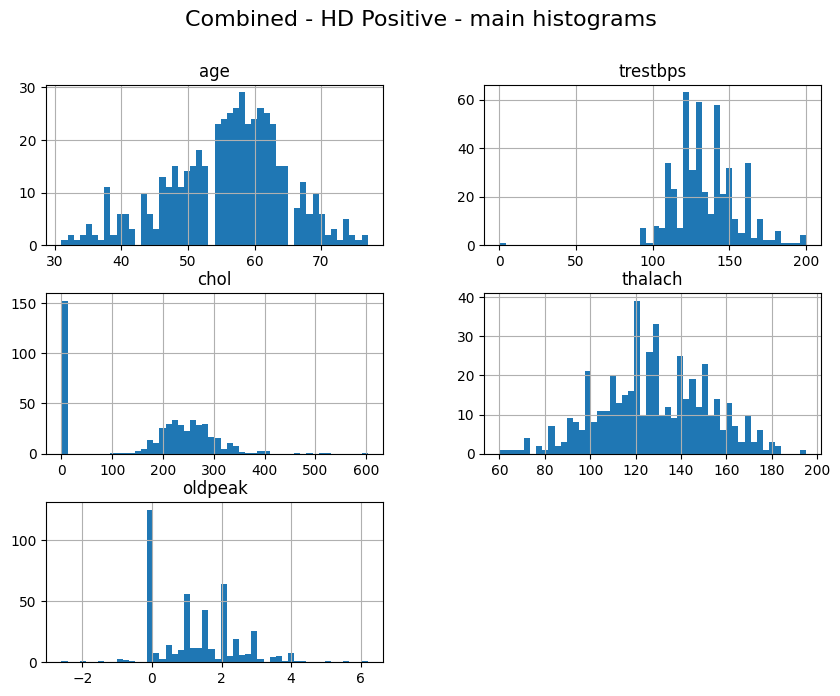

In [183]:
# main histograms - Combined - HD Positive
combined_with_for_plot[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']].astype(float).hist(bins = 50, figsize = (10,7.5))
plt.suptitle("Combined - HD Positive - main histograms", fontsize = 16)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

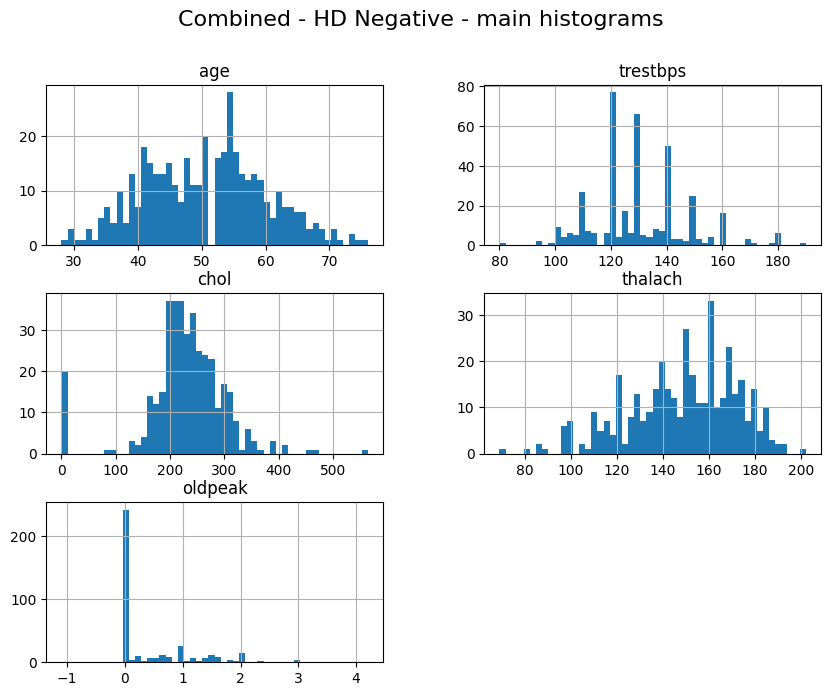

In [184]:
# main histograms - Combined - HD Negative
combined_wo_for_plot[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']].astype(float).hist(bins = 50, figsize = (10,7.5))
plt.suptitle("Combined - HD Negative - main histograms", fontsize = 16)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

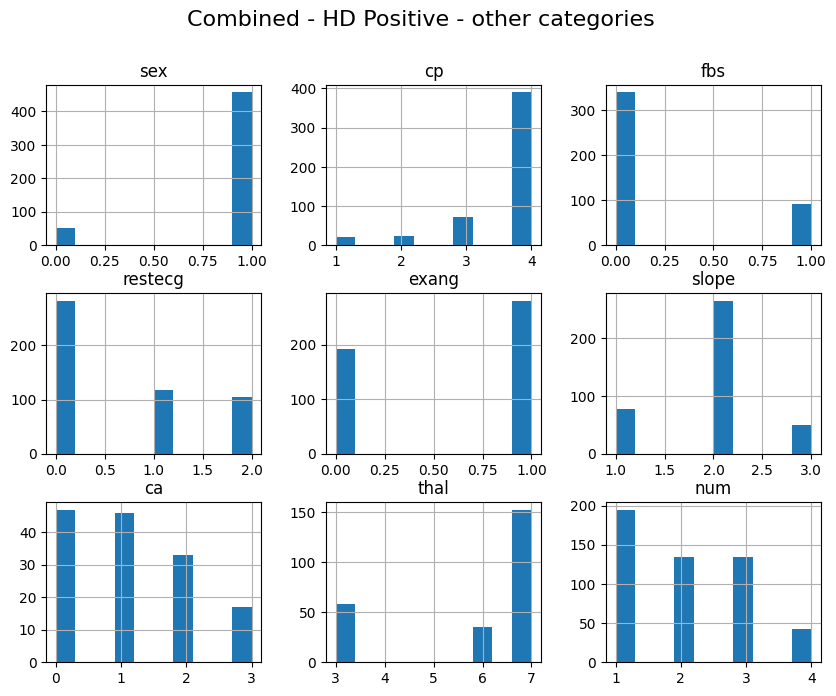

In [185]:
# look at other categories - Combined - HD Positive
combined_with_for_plot[['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'num']].astype(float).hist(figsize = (10,7.5))
plt.suptitle("Combined - HD Positive - other categories", fontsize = 16)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

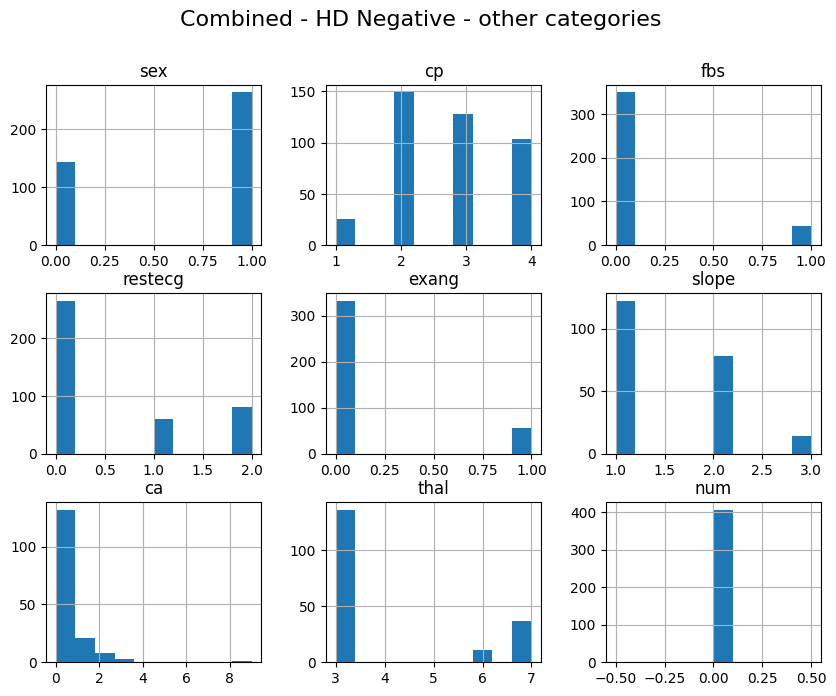

In [186]:
# look at other categories - Combined - HD Negative
combined_wo_for_plot[['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'num']].astype(float).hist(figsize = (10,7.5))
plt.suptitle("Combined - HD Negative - other categories", fontsize = 16)
plt.show